# Test different CNN architectures provided in `Landmine Detection Using Autoencoders on  Multipolarization GPR Volumetric Data` article

# Передмова
Для тесту будуть братись 3 різні архітектури згорткових мереж для 3 різних способів передачі даних

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import json
import os

## Базові параметри що будуть спільними для всіх
- **Розмір патча (висота х ширина):** 176х32. Треба додати 6 пустих відліків до оригінальної глибини, щоб глибина ідеально ділилася на 2 під час стиснення. Вікно шириною 32 траси ковзає вздовж профілю на 440 трас із кроком 17.
- **Оптимізатор:*** Adam
- **Функція активації на виході:** `tanh` (важливо щоб всі вхідні дані були в діапазоні [-1,1])
- **Архітектури стиснення:** Для кожної з категорій нижче ми проженемо три варіанти згортки:
    - **A1:** Стиснення в 16 разів (найбільше деталей).
    - **A2:** Стиснення в 32 рази.
    - **A3:** Стиснення в 64 рази (екстримальна компресія, залишає лише загальну геометрію ґрунту).

### Зберігання результатів

In [3]:
RESULTS_FILE = './gpr_full_project_results.json'

def init_full_results_storage(filename=RESULTS_FILE):
    """
    Ініціалізує єдиний JSON-файл для всіх моделей проєкту.
    """
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            print(f"Файл {filename} знайдено. Завантажуємо існуючу структуру.")
            return json.load(f)
            
    # Базовий каркас для всіх конфігурацій
    base_structure = {
        "metadata": {
            "window_size": 32,
            "step": 17,
            "epochs": 50,
            "learning_rate": 0.001,
            "optimizer": "Adam",
            "loss_function": "MSELoss"
        },
        "results": {
            "1_channel": {
                "A1_x16": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A2_x32": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A3_x64": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []}
            },
            "3_channel": {
                "A1_x16": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A2_x32": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A3_x64": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []}
            },
            "5_channel": {
                "A1_x16": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A2_x32": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []},
                "A3_x64": {"train_loss": [], "test_image_mse": [], "test_latent_mse": []}
            }
        }
    }
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(base_structure, f, indent=4)
    print(f"Створено новий глобальний файл {filename} для всіх 9 моделей.")
    
    return base_structure

def save_model_results(channel_type, model_key, train_loss, test_img_mse, test_lat_mse, filename=RESULTS_FILE):
    """
    Зберігає результати у відповідну секцію (наприклад: '1_channel', 'A1_x16').
    """
    with open(filename, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    # Перевірка на дурня
    if channel_type not in data["results"]:
        raise ValueError(f"Секції {channel_type} не існує! Використовуй 1_channel, 3_channel або 5_channel")
    if model_key not in data["results"][channel_type]:
        raise ValueError(f"Моделі {model_key} не існує в секції {channel_type}!")

    # Записуємо масиви
    data["results"][channel_type][model_key]["train_loss"] = train_loss
    data["results"][channel_type][model_key]["test_image_mse"] = test_img_mse
    data["results"][channel_type][model_key]["test_latent_mse"] = test_lat_mse
    
    # Зберігаємо на диск
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4)
        
    print(f"✅ Результати збережено: [{channel_type} -> {model_key}]")

# ==========================================
# ІНІЦІАЛІЗАЦІЯ
# ==========================================
results_db = init_full_results_storage()

Створено новий глобальний файл ./gpr_full_project_results.json для всіх 9 моделей.


### Підготовка даних
Для тренування буде зібраний 3D масив із зрізів чистого грунту (без аномалій) розмірністю 12x170x440 (надалі доповнений до 12x176x440) 

In [4]:
file_path = '../datasets/giuriati_2/20170621_deg0_HHVV.npy'
full_data = np.load(file_path, allow_pickle=True).item()

In [5]:
data = full_data['data']
gt = full_data['ground_truth']

In [6]:
print("-" * 40)
print(f"Вміст словника (ключі): {list(full_data.keys())}")
print(f"Розмірність матриці даних (Shape): {np.shape(data)}")
print(f"Розмірність розмітки (Ground Truth): {np.shape(gt)}")
print(f"Мінімальне значення: {data.min():.4f}")
print(f"Максимальне значення: {data.max():.4f}")
print("-" * 40)

----------------------------------------
Вміст словника (ключі): ['param', 'data', 'ground_truth']
Розмірність матриці даних (Shape): (66, 170, 440)
Розмірність розмітки (Ground Truth): (66,)
Мінімальне значення: -2.6768
Максимальне значення: 3.0877
----------------------------------------


In [7]:
# Очистка датасету від даних з "аномаліями"
# Отримання індексів В-сканів без аномалій
clean_indices = np.where(gt == 0)[0]
print(f"Оригінальні індекси чистих ліній: {clean_indices}")

# Отримання чистих даних
clean_data = data[clean_indices]
print(f"Розмірність сирого тренувального тензора: {clean_data.shape}")

Оригінальні індекси чистих ліній: [ 0  1  2  3  4  5  6  7  8 20 21 22]
Розмірність сирого тренувального тензора: (12, 170, 440)


#### Нормалізація датасету (Time-Varying Gain, Background Removal, Normalization)
Для деталей дивитись [обробка даних](./landmineDetectionDataReview.ipynb)

In [8]:

# Background Removal
mean_traces = np.mean(clean_data, axis=2, keepdims=True)
bg_removed = clean_data - mean_traces

# TVG
alpha = 0.015 
depth_indices = np.arange(clean_data.shape[1])
gain_curve = np.exp(alpha * depth_indices).reshape(1, -1, 1) 
tvg_applied = bg_removed * gain_curve

# Глобальна нормалізація відносно всього тренувального сету
max_val = np.max(np.abs(tvg_applied))
clean_norm = tvg_applied / max_val

In [9]:
# PADDING ДЛЯ АВТОЕНКОДЕРА (170 -> 176)
# Додаємо 6 рядків знизу (по осі 1). 
# Використовуємо mode='edge' (дублювання останнього рядка), а не нулі! 
# Раптові нулі створять штучний "обрив", який CNN сприйме як величезну аномалію на дні.
pad_width = ((0, 0), (0, 6), (0, 0)) # (лінії, глибина, траси)
train_tensor = np.pad(clean_norm, pad_width, mode='edge')

print("-" * 40)
print(f"Фінальний тензор для нарізки (Train): {train_tensor.shape}")
print(f"Мінімум: {train_tensor.min():.4f}, Максимум: {train_tensor.max():.4f}")
print("-" * 40)

----------------------------------------
Фінальний тензор для нарізки (Train): (12, 176, 440)
Мінімум: -0.8492, Максимум: 1.0000
----------------------------------------


## Категорія 1: 1 канал (1 B-scan)
Найпростіший і найшвидший варіант. Мережа дивиться лише на один профіль за раз.
- **Вхід:** Один патч із поточного В-скану
- **Формат тензора:** `(Batch_Size, 1, 176, 32)` - де 1 це кількість каналів
- **Мета тесту:** Перевірити чи достатньо лише плоского зрізу для знаходження аномалії. Якщо так, це буде найшвидша модель для інференсу в реальному часі

### Креслення моделей
Було визначено три варіанти моделі для одноканального аналізу: стиснення в 16, 32 та 64 рази відповідно

In [10]:
# Моделі

# ==========================================
# 1. Модель A1 (Стиснення x16)
# ==========================================
class DualAutoencoder1D_A1(nn.Module):
    def __init__(self):
        super(DualAutoencoder1D_A1, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU()  # Ботлнек: 16 каналів
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, x):
        z1 = self.encoder(x)          # Прогін 1: Отримуємо Z1
        x_hat = self.decoder(z1)      # Реконструкція картинки
        z2 = self.encoder(x_hat)      # Прогін 2 (Енкодер 2): Отримуємо Z2 з реконструкції
        return x_hat, z1, z2


# ==========================================
# 2. Модель A2 (Стиснення x32)
# ==========================================
class DualAutoencoder1D_A2(nn.Module):
    def __init__(self):
        super(DualAutoencoder1D_A2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1), nn.ReLU()   # Ботлнек: 8 каналів
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, x):
        z1 = self.encoder(x)
        x_hat = self.decoder(z1)
        z2 = self.encoder(x_hat)
        return x_hat, z1, z2


# ==========================================
# 3. Модель A3 (Стиснення x64)
# ==========================================
class DualAutoencoder1D_A3(nn.Module):
    def __init__(self):
        super(DualAutoencoder1D_A3, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 4, kernel_size=3, stride=2, padding=1), nn.ReLU()   # Ботлнек: 4 канали
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, x):
        z1 = self.encoder(x)
        x_hat = self.decoder(z1)
        z2 = self.encoder(x_hat)
        return x_hat, z1, z2
        

### Тренування
На цьому етапі, наявні дані будуть нарізатись і подаватись до моделі

In [11]:
class GPRDataset(Dataset):
    def __init__(self, tensor_3d, window_size=32, step=17):
        """
        tensor_3d: оригінальна матриця розміром (Лінії, Глибина, Траси)
        """
        self.data = tensor_3d
        self.window_size = window_size
        self.step = step
        
        self.num_lines = tensor_3d.shape[0]
        self.width = tensor_3d.shape[2]
        
        # Рахуємо, скільки патчів можна вирізати з однієї лінії
        self.patches_per_line = (self.width - self.window_size) // self.step + 1
        
        # Загальна кількість патчів у всьому датасеті
        self.total_patches = self.num_lines * self.patches_per_line

    def __len__(self):
        # PyTorch має знати загальний розмір, щоб правильно розбити на батчі
        return self.total_patches

    def __getitem__(self, idx):
        # Математика ковзного вікна: визначаємо координати на льоту
        line_idx = idx // self.patches_per_line
        patch_idx = idx % self.patches_per_line
        
        start_col = patch_idx * self.step
        
        # Відрізаємо шматок від оригінальної матриці (без копіювання всього масиву)
        patch = self.data[line_idx, :, start_col : start_col + self.window_size]
        
        # Конвертуємо в тензор і
        # clone() гарантує безпечну передачу в оптимізатор
        patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).clone()
        
        return patch_tensor

### Підготовка тестового датасету

In [27]:
anomaly_indices = np.where(gt == 1)[0]
test_line_idx = anomaly_indices[0] # Беремо першу-ліпшу лінію з міною (наприклад, індекс 9)
print(f"Для тестування обрано лінію з міною (індекс): {test_line_idx}")

Для тестування обрано лінію з міною (індекс): 9


In [28]:
# Витягуємо сирі дані цієї лінії -> розмір (1, 170, 440)
raw_test_line = data[test_line_idx:test_line_idx+1] 

# Застосовуємо ТУ САМУ передобробку:
# 1. Background removal
mean_test_trace = np.mean(raw_test_line, axis=2, keepdims=True)
bg_removed_test = raw_test_line - mean_test_trace

# 2. TVG (використовуємо ту саму альфу 0.015)
tvg_applied_test = bg_removed_test * gain_curve 

# 3. Нормалізація (важливо: ділимо на той самий max_val з тренувального сету, 
# щоб зберегти фізичні пропорції амплітуд!)
test_norm = tvg_applied_test / max_val

# 4. Padding (додаємо 6 відліків знизу)
test_tensor = np.pad(test_norm, pad_width, mode='edge')
print(f"Тестовий тензор готовий: {test_tensor.shape}")

Тестовий тензор готовий: (1, 176, 440)


### Ініціалізація і тренування A1_x16

In [29]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ DATALOADER ТА МОДЕЛІ A1
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Створюємо датасети
train_dataset = GPRDataset(train_tensor, window_size=32, step=17)
test_dataset = GPRDataset(test_tensor, window_size=32, step=17)

# Тренувальний перемішуємо, тестовий - НІ (щоб зберегти порядок вікон уздовж лінії)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Ініціалізуємо тільки модель A1
model_a1 = DualAutoencoder1D_A1().to(device)
epochs = 50
optimizer = optim.Adam(model_a1.parameters(), lr=0.001)
criterion_mse = nn.MSELoss()

In [30]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ A1 (x16) ===")
train_loss_history = []
model_a1.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(device)
        optimizer.zero_grad()
        
        # Нам потрібен тільки x_hat для розрахунку Loss під час навчання
        x_hat, _, _ = model_a1(batch_x) 
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ A1 (x16) ===
Епоха [01/50], Loss: 0.015102
Епоха [10/50], Loss: 0.002400
Епоха [20/50], Loss: 0.001087
Епоха [30/50], Loss: 0.000836
Епоха [40/50], Loss: 0.000704
Епоха [50/50], Loss: 0.000654


In [31]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС (Тестування)
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===")
test_image_mse = []
test_latent_mse = []
model_a1.eval()

with torch.no_grad():
    for batch_x in test_loader:
        batch_x = batch_x.to(device)
        x_hat, z1, z2 = model_a1(batch_x)
        
        # Рахуємо помилки
        img_err = criterion_mse(x_hat, batch_x).item()
        lat_err = criterion_mse(z1, z2).item()
        
        test_image_mse.append(img_err)
        test_latent_mse.append(lat_err)

# Зберігаємо в JSON
save_model_results('1_channel', 'A1_x16', train_loss_history, test_image_mse, test_latent_mse)


=== ЕТАП Б: ІНФЕРЕНС (Тестовий B-scan) ===
✅ Результати збережено: [1_channel -> A1_x16]


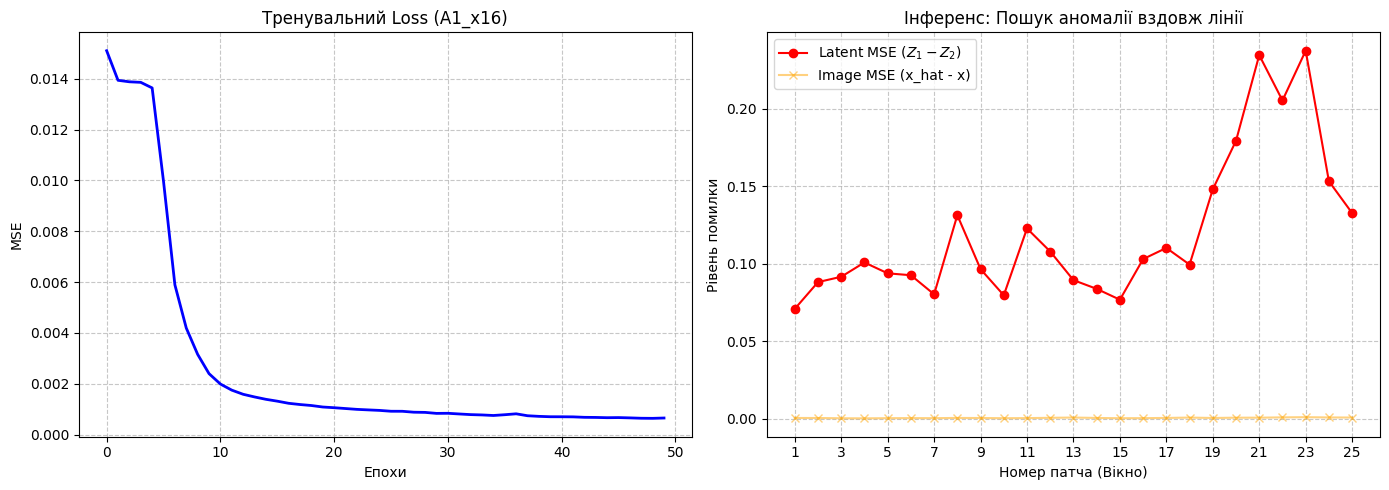

In [32]:
# ==========================================
# ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ
# ==========================================
plt.figure(figsize=(14, 5))

# Графік падіння Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, color='blue', linewidth=2)
plt.title("Тренувальний Loss (A1_x16)")
plt.xlabel("Епохи")
plt.ylabel("MSE")
plt.grid(True, linestyle='--', alpha=0.7)

# Графік пошуку міни
plt.subplot(1, 2, 2)
x_axis = np.arange(1, len(test_latent_mse) + 1)
plt.plot(x_axis, test_latent_mse, marker='o', color='red', label='Latent MSE ($Z_1 - Z_2$)')
plt.plot(x_axis, test_image_mse, marker='x', color='orange', alpha=0.5, label='Image MSE (x_hat - x)')
plt.title("Інференс: Пошук аномалії вздовж лінії")
plt.xlabel("Номер патча (Вікно)")
plt.ylabel("Рівень помилки")
plt.xticks(np.arange(1, len(test_latent_mse) + 1, step=2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Опис**<br>
- *Restored image - original image*<br>
В цьому випадку, мережа ідеально відтворила міну після декодигу, так стиснення в 16 разів дало дуже великий простір до запам'ятовування, тому Image MSE (x_hat - x) в області міни показує майже нульову похибку.<br>
- *Latent representation1 - Latent Representation2*<br>
У випадку латентного відображення, похибка росте в місці аномалії не зважаючи на ідеально відтворене зображення.




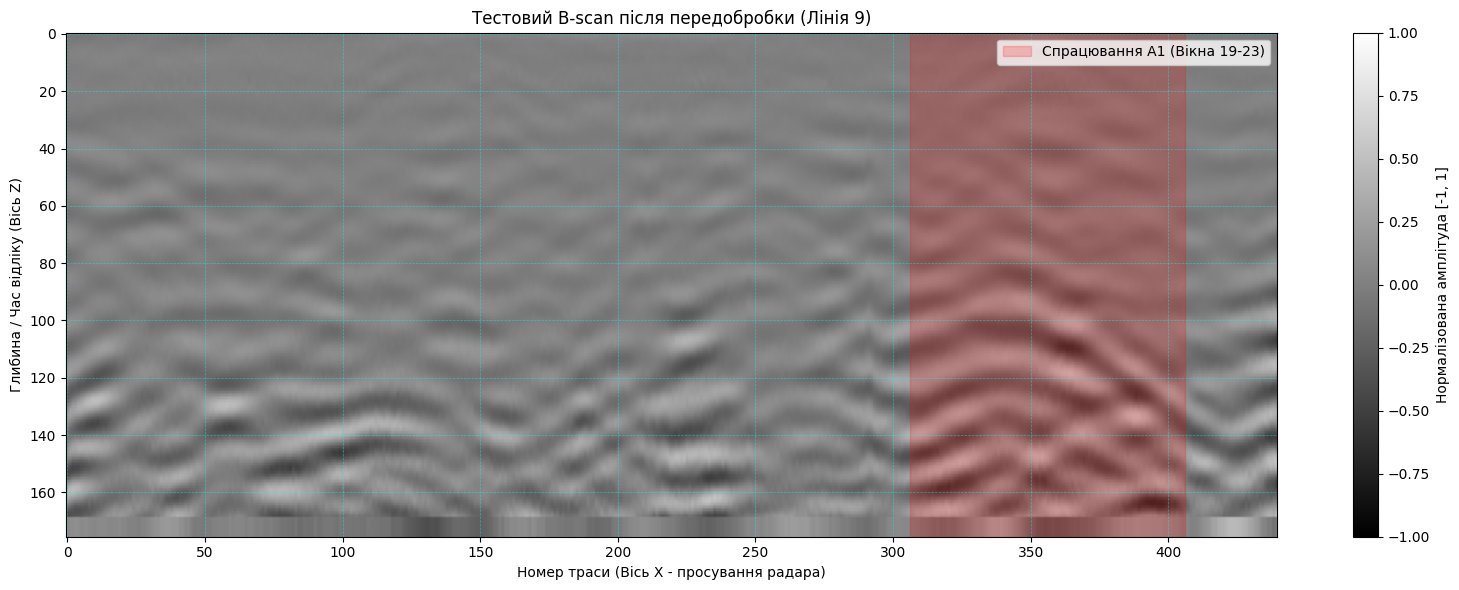

In [33]:
bscan_2d = test_tensor.squeeze()

# Якщо це PyTorch тензор, переводимо його назад у NumPy
if torch.is_tensor(bscan_2d):
    bscan_2d = bscan_2d.cpu().numpy()

plt.figure(figsize=(16, 6))

# Будуємо теплову карту.
# cmap='gray' - класичний чорно-білий радарний знімок.
# vmin=-1, vmax=1 - бо ми нормалізували дані через tanh.
img = plt.imshow(bscan_2d, aspect='auto', cmap='gray', vmin=-1, vmax=1)

# Додаємо сітку для зручності пошуку координат
plt.grid(color='cyan', linestyle='--', linewidth=0.5, alpha=0.5)

# Виділяємо зону, де мережа знайшла аномалію (Вікна 19-23)
start_anomaly = (19 - 1) * 17
end_anomaly = (23 - 1) * 17 + 32 # початок 23-го вікна + його ширина
plt.axvspan(start_anomaly, end_anomaly, color='red', alpha=0.2, label='Спрацювання A1 (Вікна 19-23)')

plt.colorbar(img, label='Нормалізована амплітуда [-1, 1]')
plt.title(f"Тестовий B-scan після передобробки (Лінія {test_line_idx})")
plt.xlabel("Номер траси (Вісь X - просування радара)")
plt.ylabel("Глибина / Час відліку (Вісь Z)")
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Ініціалізація і тренування A2_x32

In [34]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ A2 (x32)
# ==========================================
print("=== Ініціалізація A2 (Стиснення x32) ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a2 = DualAutoencoder1D_A2().to(device)

epochs = 50
learning_rate = 0.001
optimizer_a2 = optim.Adam(model_a2.parameters(), lr=learning_rate)
criterion_mse = nn.MSELoss()

# Списки для результатів
train_loss_history_a2 = []
test_image_mse_a2 = []
test_latent_mse_a2 = []

=== Ініціалізація A2 (Стиснення x32) ===


In [ ]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ A2_x32 ===")
model_a2.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer_a2.zero_grad()
        # Для тренування потрібен тільки x_hat
        x_hat, _, _ = model_a2(batch_x)
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer_a2.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history_a2.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ A2_x32 ===
Епоха [01/50], Loss: 0.013856
Епоха [10/50], Loss: 0.004157
Епоха [20/50], Loss: 0.001355
Епоха [30/50], Loss: 0.001033
Епоха [40/50], Loss: 0.000867
Епоха [50/50], Loss: 0.000796


In [36]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС НА ТЕСТОВОМУ B-SCAN
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тест на аномалію) ===")
model_a2.eval()

with torch.no_grad():
    for batch_x in test_loader:
        batch_x = batch_x.to(device)
        
        x_hat, z1, z2 = model_a2(batch_x)
        
        # 1. Помилка картинки
        img_err = criterion_mse(x_hat, batch_x).item()
        test_image_mse_a2.append(img_err)
        
        # 2. Помилка латентного простору (Feature Matching Z1 - Z2)
        lat_err = criterion_mse(z1, z2).item()
        test_latent_mse_a2.append(lat_err)

print(f"Оброблено {len(test_latent_mse_a2)} патчів.")


=== ЕТАП Б: ІНФЕРЕНС (Тест на аномалію) ===
Оброблено 25 патчів.


✅ Результати збережено: [1_channel -> A2_x32]


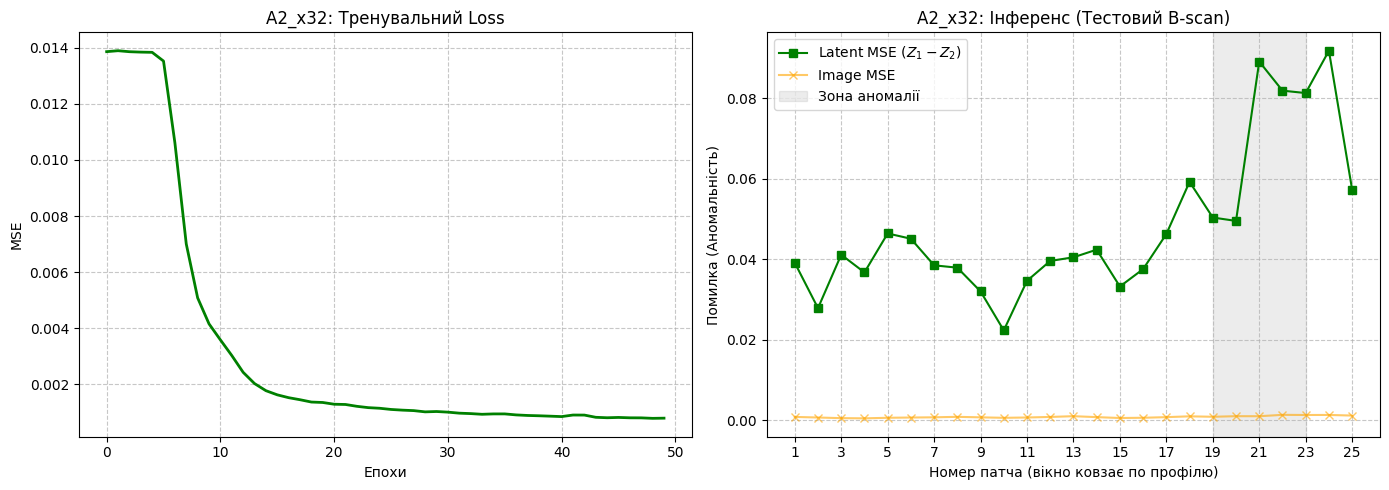

In [ ]:
# ==========================================
# ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ У БАЗУ (JSON)
# ==========================================
save_model_results(
    channel_type='1_channel', 
    model_key='A2_x32', 
    train_loss=train_loss_history_a2, 
    test_img_mse=test_image_mse_a2, 
    test_lat_mse=test_latent_mse_a2
)

# ==========================================
# ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ A2
# ==========================================
plt.figure(figsize=(14, 5))

# Графік 1: Падіння помилки при тренуванні
plt.subplot(1, 2, 1)
plt.plot(train_loss_history_a2, color='green', linewidth=2)
plt.title("A2_x32: Тренувальний Loss")
plt.xlabel("Епохи")
plt.ylabel("MSE")
plt.grid(True, linestyle='--', alpha=0.7)

# Графік 2: Пошук аномалії на тестовій лінії
plt.subplot(1, 2, 2)
x_axis = np.arange(1, len(test_latent_mse_a2) + 1)
plt.plot(x_axis, test_latent_mse_a2, marker='s', color='green', label='Latent MSE ($Z_1 - Z_2$)')
plt.plot(x_axis, test_image_mse_a2, marker='x', color='orange', alpha=0.6, label='Image MSE')

plt.axvspan(19, 23, color='gray', alpha=0.15, label='Зона аномалії')

plt.title("A2_x32: Інференс (Тестовий B-scan)")
plt.xlabel("Номер патча (вікно ковзає по профілю)")
plt.ylabel("Помилка (Аномальність)")
plt.xticks(np.arange(1, len(test_latent_mse_a2) + 1, step=2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Ініціалізація і тренування A2_x32

In [38]:
# ==========================================
# ІНІЦІАЛІЗАЦІЯ МОДЕЛІ A3 (x64)
# ==========================================
print("=== Ініціалізація A3 (Стиснення x64) ===")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_a3 = DualAutoencoder1D_A3().to(device)

epochs = 50
learning_rate = 0.001
optimizer_a3 = optim.Adam(model_a3.parameters(), lr=learning_rate)
criterion_mse = nn.MSELoss()

train_loss_history_a3 = []
test_image_mse_a3 = []
test_latent_mse_a3 = []

=== Ініціалізація A3 (Стиснення x64) ===


In [39]:
# ==========================================
# ЕТАП А: ТРЕНУВАННЯ A3_x64
# ==========================================
print("\n=== ЕТАП А: ТРЕНУВАННЯ A3_x64 ===")
model_a3.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x in train_loader:
        batch_x = batch_x.to(device)
        
        optimizer_a3.zero_grad()
        x_hat, _, _ = model_a3(batch_x)
        
        loss = criterion_mse(x_hat, batch_x)
        loss.backward()
        optimizer_a3.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(train_loader)
    train_loss_history_a3.append(avg_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Епоха [{epoch+1:02d}/{epochs}], Loss: {avg_loss:.6f}")


=== ЕТАП А: ТРЕНУВАННЯ A3_x64 ===
Епоха [01/50], Loss: 0.015744
Епоха [10/50], Loss: 0.013863
Епоха [20/50], Loss: 0.013846
Епоха [30/50], Loss: 0.013814
Епоха [40/50], Loss: 0.013834
Епоха [50/50], Loss: 0.013840


In [40]:
# ==========================================
# ЕТАП Б: ІНФЕРЕНС НА ТЕСТОВОМУ B-SCAN
# ==========================================
print("\n=== ЕТАП Б: ІНФЕРЕНС (Тест на аномалію) ===")
model_a3.eval()

with torch.no_grad():
    for batch_x in test_loader:
        batch_x = batch_x.to(device)
        
        x_hat, z1, z2 = model_a3(batch_x)
        
        test_image_mse_a3.append(criterion_mse(x_hat, batch_x).item())
        test_latent_mse_a3.append(criterion_mse(z1, z2).item())

print(f"Оброблено {len(test_latent_mse_a3)} патчів.")


=== ЕТАП Б: ІНФЕРЕНС (Тест на аномалію) ===
Оброблено 25 патчів.


✅ Результати збережено: [1_channel -> A3_x64]


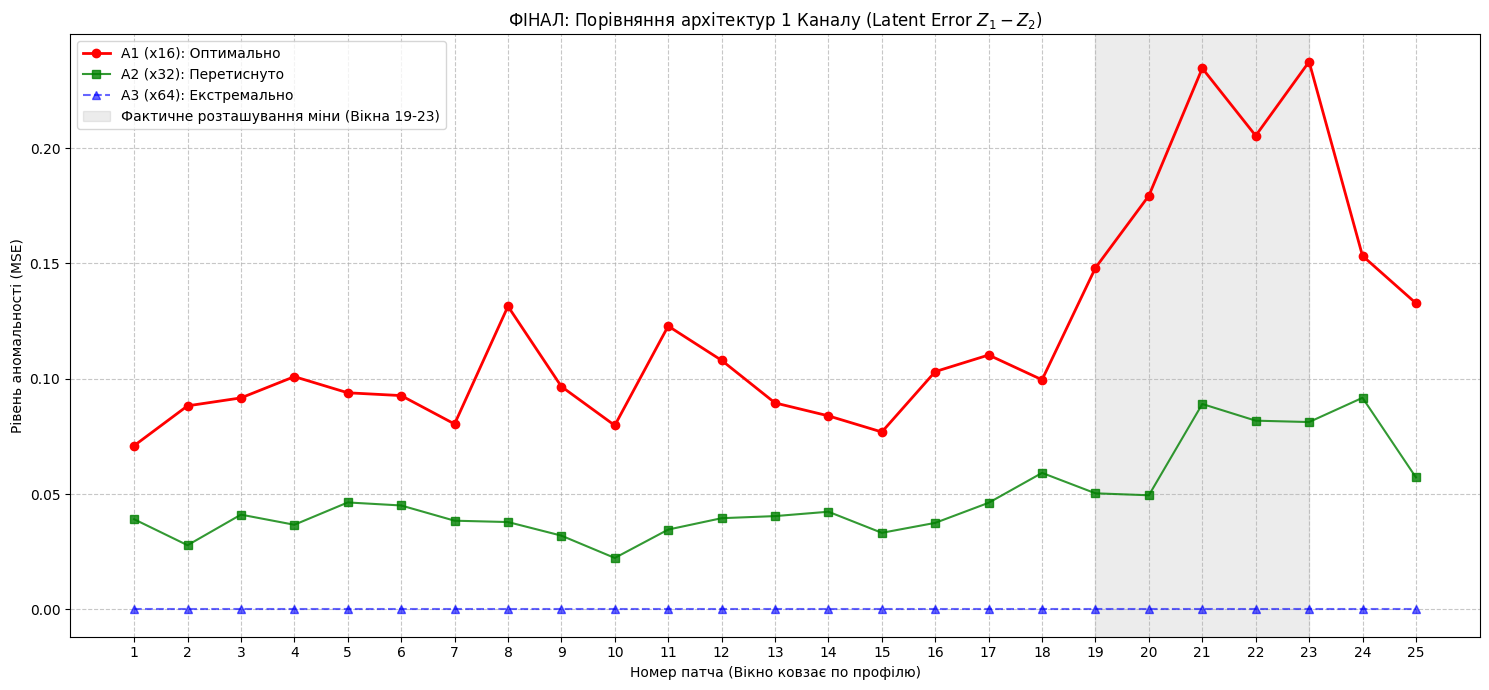

In [41]:
# ==========================================
# ЗБЕРЕЖЕННЯ РЕЗУЛЬТАТІВ У JSON
# ==========================================
save_model_results(
    channel_type='1_channel', 
    model_key='A3_x64', 
    train_loss=train_loss_history_a3, 
    test_img_mse=test_image_mse_a3, 
    test_lat_mse=test_latent_mse_a3
)

# ==========================================
# ФІНАЛЬНЕ ПОРІВНЯННЯ 1-КАНАЛЬНИХ АРХІТЕКТУР (A1 vs A2 vs A3)
# ==========================================
# Читаємо всі збережені дані з нашої бази
with open(RESULTS_FILE, 'r', encoding='utf-8') as f:
    all_data = json.load(f)
    lat_mse_a1 = all_data['results']['1_channel']['A1_x16']['test_latent_mse']
    lat_mse_a2 = all_data['results']['1_channel']['A2_x32']['test_latent_mse']
    lat_mse_a3 = all_data['results']['1_channel']['A3_x64']['test_latent_mse']

plt.figure(figsize=(15, 7))
x_axis = np.arange(1, len(lat_mse_a1) + 1)

# Будуємо три лінії Latent MSE на одному графіку
plt.plot(x_axis, lat_mse_a1, marker='o', linestyle='-', color='red', linewidth=2, label='A1 (x16): Оптимально')
plt.plot(x_axis, lat_mse_a2, marker='s', linestyle='-', color='green', linewidth=1.5, alpha=0.8, label='A2 (x32): Перетиснуто')
plt.plot(x_axis, lat_mse_a3, marker='^', linestyle='--', color='blue', linewidth=1.5, alpha=0.6, label='A3 (x64): Екстремально')

# Виділяємо зону міни
plt.axvspan(19, 23, color='gray', alpha=0.15, label='Фактичне розташування міни (Вікна 19-23)')

plt.title("ФІНАЛ: Порівняння архітектур 1 Каналу (Latent Error $Z_1 - Z_2$)")
plt.xlabel("Номер патча (Вікно ковзає по профілю)")
plt.ylabel("Рівень аномальності (MSE)")
plt.xticks(np.arange(1, len(x_axis) + 1, step=1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize='10')

plt.tight_layout()
plt.show()

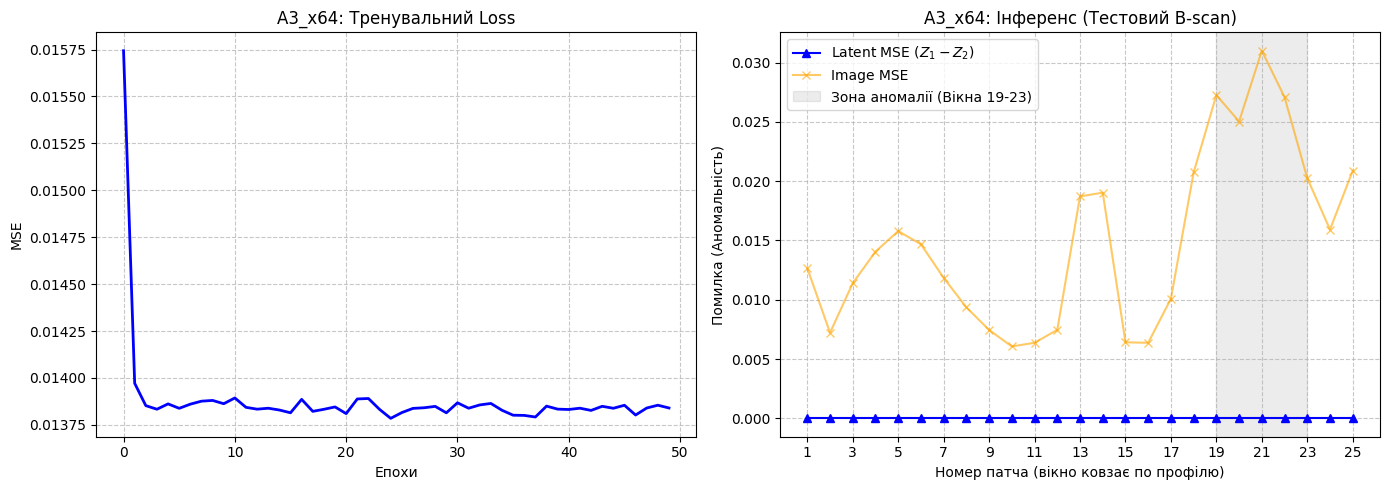

In [42]:
# ==========================================
# ВІЗУАЛІЗАЦІЯ ІНДИВІДУАЛЬНИХ РЕЗУЛЬТАТІВ A3
# ==========================================
plt.figure(figsize=(14, 5))

# Графік 1: Падіння помилки при тренуванні
plt.subplot(1, 2, 1)
plt.plot(train_loss_history_a3, color='blue', linewidth=2)
plt.title("A3_x64: Тренувальний Loss")
plt.xlabel("Епохи")
plt.ylabel("MSE")
plt.grid(True, linestyle='--', alpha=0.7)

# Графік 2: Пошук аномалії на тестовій лінії
plt.subplot(1, 2, 2)
x_axis = np.arange(1, len(test_latent_mse_a3) + 1)
plt.plot(x_axis, test_latent_mse_a3, marker='^', color='blue', label='Latent MSE ($Z_1 - Z_2$)')
plt.plot(x_axis, test_image_mse_a3, marker='x', color='orange', alpha=0.6, label='Image MSE')

# Виділяємо зону, де фактично лежить міна
plt.axvspan(19, 23, color='gray', alpha=0.15, label='Зона аномалії (Вікна 19-23)')

plt.title("A3_x64: Інференс (Тестовий B-scan)")
plt.xlabel("Номер патча (вікно ковзає по профілю)")
plt.ylabel("Помилка (Аномальність)")
plt.xticks(np.arange(1, len(test_latent_mse_a3) + 1, step=2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Категорія 2: 3 канали (Псевдо-3D/3 канали)
Імітація роботи із RGB-зображенням.
- **Вхід:** Три однакові патчі з трьох сусідніх В-сканів (лінії *i-1, i, i+1*), накладені один на одного
- **Формат тензора:** `(Batch_Size, 3, 176, 32)` - де 3 це канали, як в RGB
- **Мета тесту:** Перевірити гіпотезу зі статті. Мережа має навчитися розуміти, що справжній об'єкт (як труба чи велика міна) має "відлуння" на сусідніх лініях сканування, а випадковий камінь - ні. Це має різко зменшити кількість хибних спрацьовувань (False Positives).

## Категорія 3: 5 каналів (Розширене псевдо-3D/5 канали)
Модифікація для пошуку великих або протяжних об'єктів (наприклад, протитанкових мін (ТМ-62)  або довгого будівельного сміття)
- **Вхід:** П'ять патчів із п'яти сусідніх В-сканів (лінії *i-2, i-1, i, i+1, i+2*).
- **Формат тензора:** `(Batch_Size, 5, 176, 32)`.
- **Технічний нюанс:** Оскільки береться вікно з 5 ліній, неможливо відцентрувати його на перших і останніх двох лініях датасету. Ці краї доведеться ігнорувати під час тренування. Враховуючи всього 12  ліній без мін, з них стоять поряд 9 та 3, можливість тренування дуже обмежена. 
- **Мета тесту:** Перевірити, чи дає розширення просторового контексту до 5 ліній приріст точності, чи просто уповільнює навчання і перевантажує латентний простір сміттям. 

### Тестування
Індекатором аномалії буде (Reconstruction Error) із оцінкою MSE (Mean Square Error) та MAE (Mean Absolute Error) між оригінальним патчем та тим, що згенерував декодер.

- **Етап А: Тренування (Baseline)**<br>
Моделі згодовується набір даних відповідної розмірності. На цьому етапі особлива увага приділяється лише графіку Loss. Якщо Loss падає і стабілізується на низькому рівні - модель успішно вивчила фізику ґрунту. Якщо Loss залишається високим (що ймовірно для жорсткого стиснення А3) - модель не здатна відтворити навіть фон.
- **Етап Б: Інферренс (Тест на даних із "аномаліями")**<br>
Береться тестовий В-скан **із міною** (з тієї частини датасету, на якій не проходило тренування). Пропускається ковзне вікно через цей В-скан (25 патчів). Розраховується загальний `MSE`
- **Етап В: Аналіз графіку помилок**<br>
Будується графік (вісь Х - номери патчів від 1 до 25, Y - значення помилки `MSE`).


**Найкраща модель**<br>
Найкращою архітектурою буде та, що дає найбільшу *дельту* між середньою помилкою на фонових патчах та піковою помилкою на аномальному патчі.
